# Workstream A — Insight
Who churns and why: data audit, demographics, churn reasons.


In [21]:
## Imports
## Importing the big 4 - Pandas, Numpy, Seaborn & matplotlib
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
## Import the metrics we'll be using
from sklearn import metrics
## Import Logistic Regression from sklearn
from sklearn.linear_model import LogisticRegression
import plotly.express as px

In [6]:
df = pd.read_excel('Swan Consulting 1 - Project Data.xlsx')

In [38]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Reason'],
      dtype='str')

In [7]:
df_churned = df[df['Churn Value'] == 1]

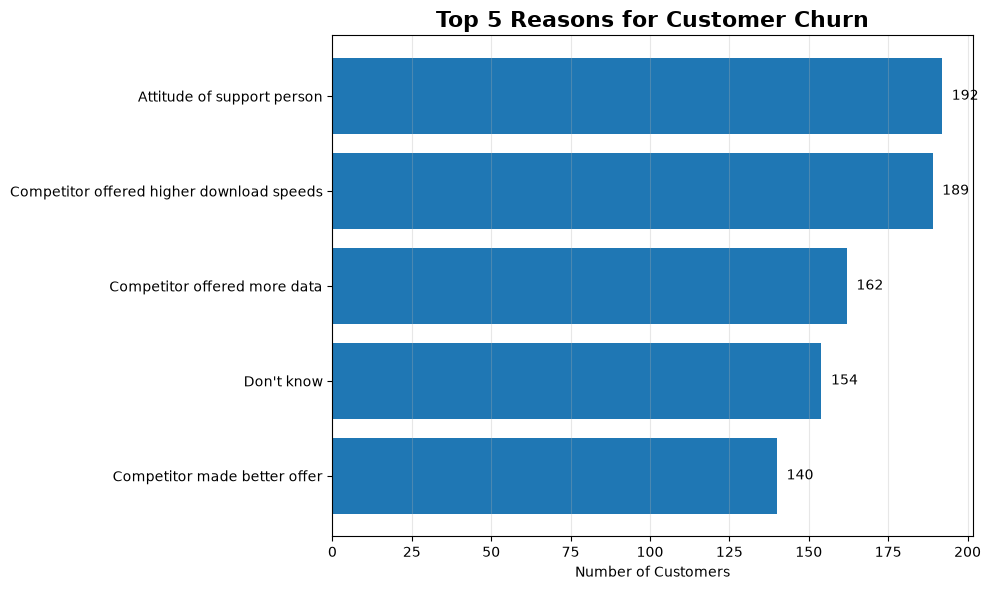

In [16]:
top_5_reasons = df_churned["Churn Reason"].value_counts().head(5)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_5_reasons.index,
    top_5_reasons.values
)

plt.title("Top 5 Reasons for Customer Churn", fontsize=16, fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [46]:

demographic_cols = ["Gender", "Senior Citizen", "Partner", "Dependents"]
customer_relationships = ['Tenure Months', 'Contract', 'Payment Method', 'Monthly Charges']
products = ['Internet Service', 'Online Security', 'Tech Support']


def churn_rate(cols, bins=5):
    results = []

    for col in cols:

        # Continuous numerical columns
        if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 10:
            
            categories = pd.qcut(
                df[col],
                q=bins,
                duplicates="drop"
            )

            churn_rates = df.groupby(
                categories,
                observed=True
            )["Churn Value"].mean()

        # Categorical / binary columns
        else:
            churn_rates = df.groupby(
                col
            )["Churn Value"].mean()

        for category, rate in churn_rates.items():
            results.append({
                "Factor": col,
                "Category": str(category),
                "Churn Rate": rate
            })

    return pd.DataFrame(results)

demo_churn = churn_rate(demographic_cols)
realtionships_churn = churn_rate(customer_relationships)






In [48]:
net = df[df["Internet Service"] != "No"]

def churn_rate_net(cols, bins=5):
    results = []

    for col in cols:

        # Continuous numerical columns
        if pd.api.types.is_numeric_dtype(net[col]) and net[col].nunique() > 10:
            
            categories = pd.qcut(
                net[col],
                q=bins,
                duplicates="drop"
            )

            churn_rates = net.groupby(
                categories,
                observed=True
            )["Churn Value"].mean()

        # Categorical / binary columns
        else:
            churn_rates = net.groupby(
                col
            )["Churn Value"].mean()

        for category, rate in churn_rates.items():
            results.append({
                "Factor": col,
                "Category": str(category),
                "Churn Rate": rate
            })

    return pd.DataFrame(results)

products_churn = churn_rate_net(products)

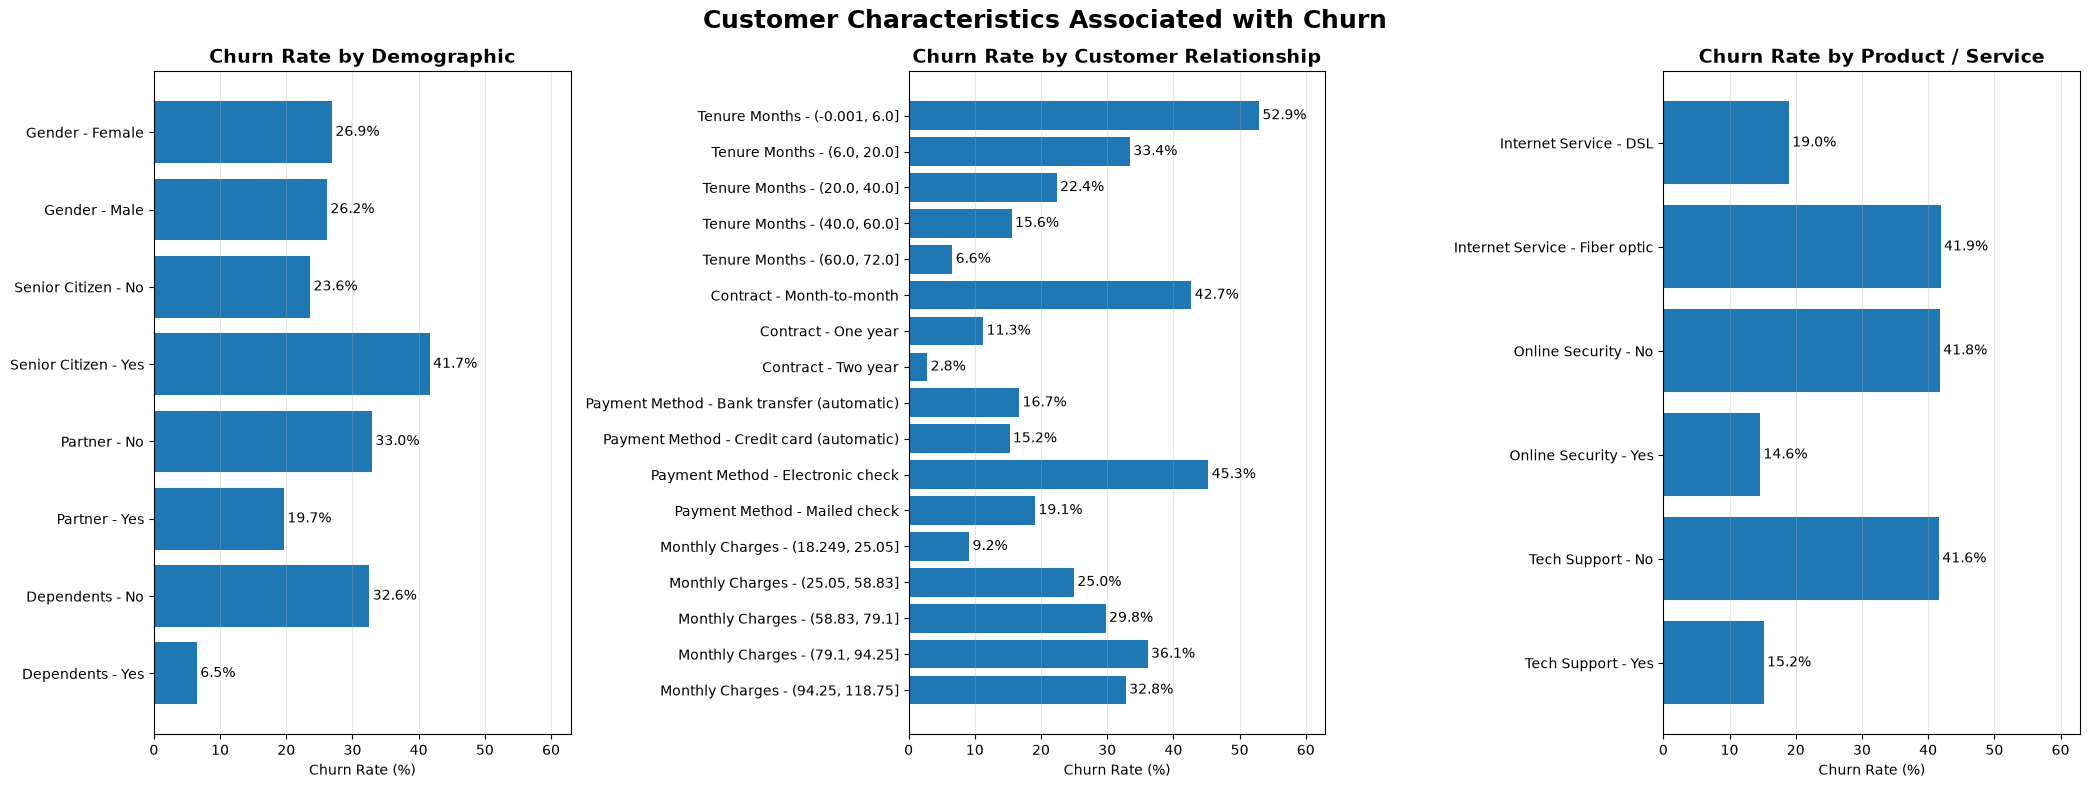

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

# -------------------------
# 1. Demographics
# -------------------------

demo_labels = (
    demo_churn["Factor"] + " - " + demo_churn["Category"]
)

bars1 = axes[0].barh(
    demo_labels,
    demo_churn["Churn Rate"] * 100
)

axes[0].set_title("Churn Rate by Demographic", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Churn Rate (%)")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)

for bar in bars1:
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}%",
        va="center"
    )


# -------------------------
# 2. Customer relationships
# -------------------------

relationship_labels = (
    realtionships_churn["Factor"] + " - " + realtionships_churn["Category"]
)

bars2 = axes[1].barh(
    relationship_labels,
    realtionships_churn["Churn Rate"] * 100
)

axes[1].set_title("Churn Rate by Customer Relationship", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Churn Rate (%)")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)

for bar in bars2:
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}%",
        va="center"
    )


# -------------------------
# 3. Products / services
# -------------------------

product_labels = (
    products_churn["Factor"] + " - " + products_churn["Category"]
)

bars3 = axes[2].barh(
    product_labels,
    products_churn["Churn Rate"] * 100
)

axes[2].set_title("Churn Rate by Product / Service", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Churn Rate (%)")
axes[2].invert_yaxis()
axes[2].grid(axis="x", alpha=0.3)

for bar in bars3:
    axes[2].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}%",
        va="center"
    )


# -------------------------
# Make scales consistent
# -------------------------

max_rate = max(
    demo_churn["Churn Rate"].max(),
    realtionships_churn["Churn Rate"].max(),
    products_churn["Churn Rate"].max()
) * 100

for ax in axes:
    ax.set_xlim(0, max_rate + 10)


plt.suptitle(
    "Customer Characteristics Associated with Churn",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [68]:
pd.crosstab(
    df_churned["Contract"],
    df_churned["Churn Reason"],
    normalize="index"
) * 100

Churn Reason,Attitude of service provider,Attitude of support person,Competitor had better devices,Competitor made better offer,Competitor offered higher download speeds,Competitor offered more data,Deceased,Don't know,Extra data charges,Lack of affordable download/upload speed,Lack of self-service on Website,Limited range of services,Long distance charges,Moved,Network reliability,Poor expertise of online support,Poor expertise of phone support,Price too high,Product dissatisfaction,Service dissatisfaction
Contract,,,,,,,,,,,,,,,,,,,,
Month-to-month,6.948640,10.513595,7.009063,7.613293,9.728097,8.459215,0.362538,8.519637,3.202417,2.175227,5.075529,2.416918,2.235650,2.598187,5.558912,1.087613,0.966767,5.377644,5.135952,5.015106
One year,10.240964,9.638554,6.024096,6.024096,13.855422,9.638554,0.000000,7.228916,0.602410,3.012048,1.204819,2.409639,3.012048,6.024096,6.024096,0.602410,1.807229,3.614458,6.024096,3.012048
Two year,6.250000,4.166667,8.333333,8.333333,10.416667,12.500000,0.000000,2.083333,6.250000,6.250000,4.166667,0.000000,4.166667,0.000000,2.083333,0.000000,2.083333,6.250000,14.583333,2.083333


In [69]:
df_churned["Tenure Band"] = pd.cut(
    df_churned["Tenure Months"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

pd.crosstab(
    df_churned["Tenure Band"],
    df_churned["Churn Reason"],
    normalize="index"
) * 100

Churn Reason,Attitude of service provider,Attitude of support person,Competitor had better devices,Competitor made better offer,Competitor offered higher download speeds,Competitor offered more data,Deceased,Don't know,Extra data charges,Lack of affordable download/upload speed,Lack of self-service on Website,Limited range of services,Long distance charges,Moved,Network reliability,Poor expertise of online support,Poor expertise of phone support,Price too high,Product dissatisfaction,Service dissatisfaction
Tenure Band,,,,,,,,,,,,,,,,,,,,
0-12,7.232401,10.125362,7.521697,8.389585,9.546770,8.582449,0.385728,7.907425,2.796528,2.217936,4.725169,2.796528,2.314368,2.603664,6.268081,1.157184,0.964320,5.303761,5.014465,4.146577
13-24,7.823129,11.564626,7.482993,5.442177,11.224490,7.823129,0.680272,8.843537,2.040816,1.700680,6.462585,2.380952,2.721088,3.061224,4.421769,0.680272,0.680272,3.741497,5.102041,6.122449
25-48,6.461538,9.538462,5.230769,8.307692,8.923077,7.692308,0.000000,10.461538,4.000000,3.076923,4.615385,2.153846,0.923077,3.076923,4.000000,1.538462,2.153846,6.153846,6.153846,5.538462
49-72,7.511737,10.328638,6.103286,4.694836,13.145540,11.737089,0.000000,5.633803,4.225352,2.816901,2.347418,0.469484,4.225352,3.286385,5.633803,0.000000,0.469484,5.633803,7.042254,4.694836


In [71]:

churn_categories = {
    "Competitor-related": [
        "Competitor had better devices",
        "Competitor made better offer",
        "Competitor offered higher download speeds",
        "Competitor offered more data"
    ],
    "Price / value": [
        "Price too high",
        "Extra data charges",
        "Long distance charges",
        "Lack of affordable download/upload speed"
    ],
    "Service / support experience": [
        "Attitude of service provider",
        "Attitude of support person",
        "Poor expertise of online support",
        "Poor expertise of phone support",
        "Lack of self-service on Website"
    ],
    "Product / service quality": [
        "Product dissatisfaction",
        "Service dissatisfaction",
        "Network reliability",
        "Limited range of services"
    ],
    "Personal / unavoidable": [
        "Moved",
        "Deceased"
    ],
    "Unknown / unclear": [
        "Don't know"
    ]
}

churn_category_df = pd.DataFrame(
    [
        {"Churn Reason": reason, "Churn Category": category}
        for category, reasons in churn_categories.items()
        for reason in reasons
    ]
)



In [73]:
# Add the category column if it has not been added yet
reason_to_category = {
    reason: category
    for category, reasons in churn_categories.items()
    for reason in reasons
}

df_churned["Churn Category"] = (
    df_churned["Churn Reason"].map(reason_to_category)
)

# Count churn by category
category_churn_counts = (
    df_churned["Churn Category"]
    .value_counts()
    .rename_axis("Churn Category")
    .reset_index(name="Churn Count")
)

category_churn_counts

,Churn Category,Churn Count
0,Competitor-related,621
1,Service / support experience,454
2,Product / service quality,338
3,Price / value,243
4,Unknown / unclear,154
5,Personal / unavoidable,59


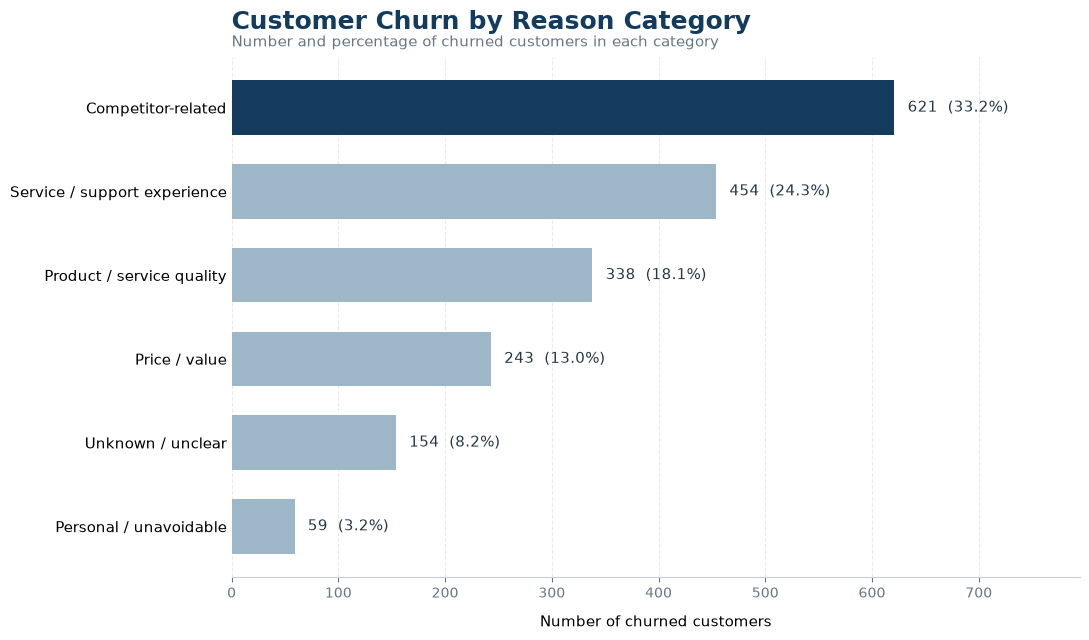

In [75]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Prepare data
plot_data = category_churn_counts.sort_values(
    "Churn Count", ascending=False
).reset_index(drop=True)

plot_data["Percentage"] = (
    plot_data["Churn Count"] / plot_data["Churn Count"].sum()
)

# Highlight the leading category
colors = ["#123B5D"] + ["#9DB7C9"] * (len(plot_data) - 1)

# Create chart
fig, ax = plt.subplots(figsize=(11, 6.5))

bars = ax.barh(
    plot_data["Churn Category"],
    plot_data["Churn Count"],
    color=colors,
    height=0.65
)

ax.invert_yaxis()

# Add count and percentage labels
max_count = plot_data["Churn Count"].max()

for bar, count, percentage in zip(
    bars,
    plot_data["Churn Count"],
    plot_data["Percentage"]
):
    ax.text(
        count + max_count * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}  ({percentage:.1%})",
        va="center",
        fontsize=11,
        color="#253746"
    )

# Titles
ax.set_title(
    "Customer Churn by Reason Category",
    loc="left",
    fontsize=18,
    fontweight="bold",
    color="#123B5D",
    pad=20
)

ax.text(
    0,
    1.02,
    "Number and percentage of churned customers in each category",
    transform=ax.transAxes,
    fontsize=11,
    color="#667784"
)

# Styling
ax.set_xlabel("Number of churned customers", fontsize=11, labelpad=10)
ax.set_ylabel("")

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.xaxis.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.set_xlim(0, max_count * 1.28)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#C7D0D8")

ax.tick_params(axis="y", length=0, labelsize=11)
ax.tick_params(axis="x", colors="#667784")

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
plt.show()